# Stroke Prediction Dataset — Análise Exploratória de Dados (EDA)
## APS1 — Parte 2/2: Análise Multivariada, PCA e Pipeline de Pré-processamento

**Título do projeto:** Predição de AVC (Stroke) — Análise Exploratória e Preparação dos Dados para Classificação

**Disciplina:** Machine Learning

**Membros do grupo (dupla):**
- Membro 1 — **Erick Barbosa** — responsável pela Parte 1 (Inspeção, Análise Univariada e Bivariada)
- Membro 2 — **Rafael Lemos** — responsável pela Parte 2 (Análise Multivariada, PCA e Pipeline)

**Data de entrega:** 14/09/2026

**Dataset:** [Stroke Prediction Dataset — Kaggle (fedesoriano)](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

**Referências bibliográficas:**
1. FEDESORIANO. *Stroke Prediction Dataset*. Kaggle, 2021. Disponível em: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
2. PEDREGOSA, F. et al. *Scikit-learn: Machine Learning in Python*. JMLR 12, pp. 2825-2830, 2011.
3. JOLLIFFE, I. T.; CADIMA, J. *Principal component analysis: a review and recent developments*. Phil. Trans. R. Soc. A, 2016.
4. TUKEY, J. W. *Exploratory Data Analysis*. Addison-Wesley, 1977. (Método do intervalo interquartil — IQR — para detecção de outliers.)
5. Documentação oficial do Scikit-learn: `ColumnTransformer`, `Pipeline`, `OneHotEncoder`, `StandardScaler`, `PCA` — https://scikit-learn.org/stable/

---

### Sobre esta segunda parte

Esta segunda parte do notebook é de responsabilidade do **Membro 2** e cobre:

1. Análise multivariada (boxplots cruzando variáveis numéricas, categóricas e o *target*) e diagnóstico formal de outliers;
2. Redução de dimensionalidade com PCA sobre as variáveis numéricas padronizadas, com análise de variância explicada e separabilidade das classes;
3. Justificativa teórica/prática das estratégias de pré-processamento (imputação, encoding, escalonamento);
4. Construção do `ColumnTransformer` + `Pipeline` do scikit-learn, separação treino/teste estratificada e exportação do pipeline — sem *data leakage* — para uso na APS2 (modelagem).

Para que este notebook seja **executável de forma independente** (sem depender de variáveis já criadas na Parte 1), recarregamos e re-inspecionamos brevemente os dados abaixo antes de avançar para as tarefas específicas do Membro 2.


## 0. Configuração do ambiente e carregamento dos dados

In [1]:
# Bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

import joblib
import warnings
warnings.filterwarnings("ignore")

# Reprodutibilidade: random_state fixo em TODAS as etapas amostrais do notebook
RANDOM_STATE = 42

# Paleta de cores acessível (colorblind-friendly) e estilo dos gráficos
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)


In [2]:
# Carregamento do dataset
# Tenta primeiro um arquivo local (ex.: baixado manualmente do Kaggle e salvo ao lado do notebook,
# mesmo procedimento adotado na Parte 1 pelo Membro 1). Caso não encontre localmente, faz o download
# de uma cópia íntegra do dataset original (mesmo shape e mesmas estatísticas do arquivo do Kaggle)
# hospedada publicamente no GitHub, garantindo reprodutibilidade em qualquer ambiente (local ou Colab).

import os

LOCAL_CANDIDATES = [
    "healthcare-dataset-stroke-data.csv",
    "aps1/healthcare-dataset-stroke-data.csv",
    "/content/healthcare-dataset-stroke-data.csv",
]
FALLBACK_URL = (
    "https://raw.githubusercontent.com/YuvrazError/Healthcare-Dataset-Analysis/"
    "main/healthcare-dataset-stroke-data.csv"
)

path = next((p for p in LOCAL_CANDIDATES if os.path.exists(p)), None)
df = pd.read_csv(path if path else FALLBACK_URL, na_values=["N/A"])

print(f"Fonte dos dados: {'arquivo local -> ' + path if path else 'download remoto (cópia do Kaggle)'}")
print(f"Shape: {df.shape[0]} instâncias x {df.shape[1]} features")
df.head()


Fonte dos dados: arquivo local -> healthcare-dataset-stroke-data.csv
Shape: 5110 instâncias x 12 features


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Recapitulação rápida (já detalhada na Parte 1 pelo Membro 1):** o dataset possui 5.110 instâncias e 12 colunas (`id`, `gender`, `age`, `hypertension`, `heart_disease`, `ever_married`, `work_type`, `Residence_type`, `avg_glucose_level`, `bmi`, `smoking_status` e o *target* `stroke`). A coluna `bmi` possui 201 valores ausentes (~3,9%) e o *target* é fortemente desbalanceado: apenas ~4,9% das instâncias correspondem a casos de AVC (`stroke = 1`). A coluna `id` é apenas um identificador e será descartada do pipeline de modelagem por não carregar informação preditiva.

In [3]:
df = df.drop(columns=["id"])
print("Valores ausentes por coluna:")
print(df.isna().sum())
print()
print("Balanceamento do target (stroke):")
print(df["stroke"].value_counts(normalize=True).rename("proporção").round(4))


Valores ausentes por coluna:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Balanceamento do target (stroke):
stroke
0    0.9513
1    0.0487
Name: proporção, dtype: float64


## 1. Análise Multivariada e Diagnóstico de Outliers

Nesta seção avaliamos como uma variável **numérica** se comporta simultaneamente em função de uma variável **categórica** e do **target** (`stroke`), usando *boxplots* agrupados (`hue`). O objetivo é identificar padrões de risco que só aparecem quando cruzamos três dimensões ao mesmo tempo (ex.: será que o efeito da glicemia sobre o risco de AVC é diferente entre hipertensos e não hipertensos?).

Limite de 3 gráficos, conforme especificado no enunciado.

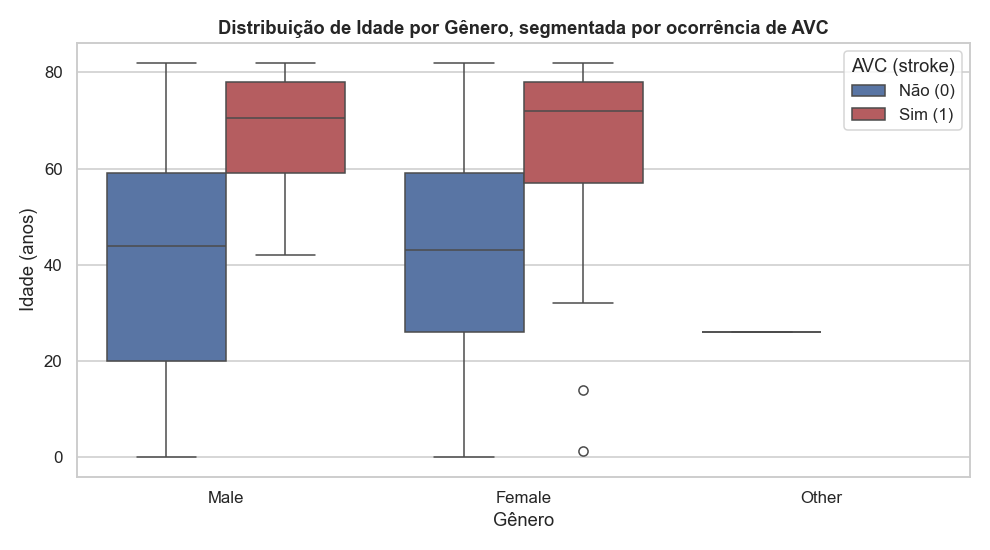

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x="gender", y="age", hue="stroke",
    palette=["#4C72B0", "#C44E52"], ax=ax
)
ax.set_title("Distribuição de Idade por Gênero, segmentada por ocorrência de AVC")
ax.set_xlabel("Gênero")
ax.set_ylabel("Idade (anos)")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Não (0)", "Sim (1)"], title="AVC (stroke)")
plt.tight_layout()
plt.show()


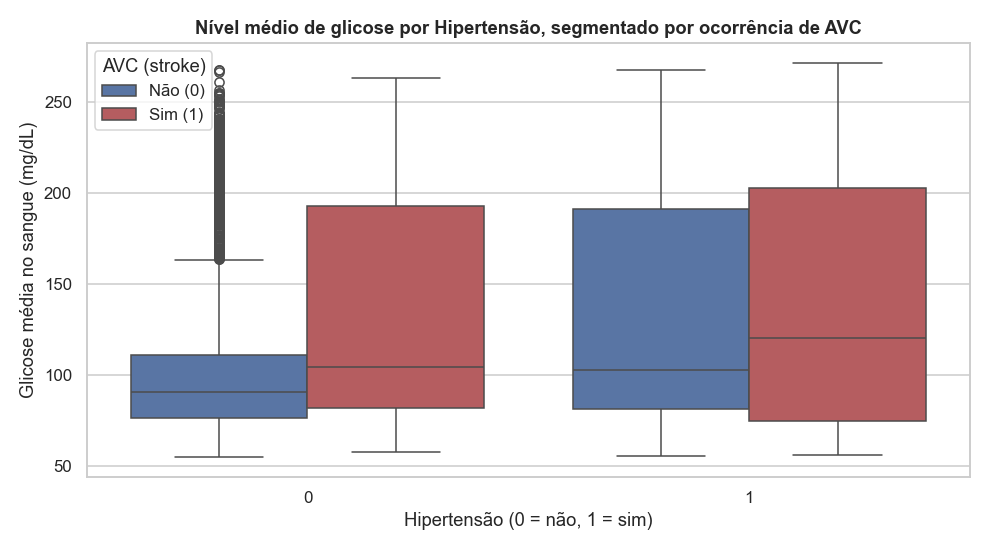

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x="hypertension", y="avg_glucose_level", hue="stroke",
    palette=["#4C72B0", "#C44E52"], ax=ax
)
ax.set_title("Nível médio de glicose por Hipertensão, segmentado por ocorrência de AVC")
ax.set_xlabel("Hipertensão (0 = não, 1 = sim)")
ax.set_ylabel("Glicose média no sangue (mg/dL)")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Não (0)", "Sim (1)"], title="AVC (stroke)")
plt.tight_layout()
plt.show()


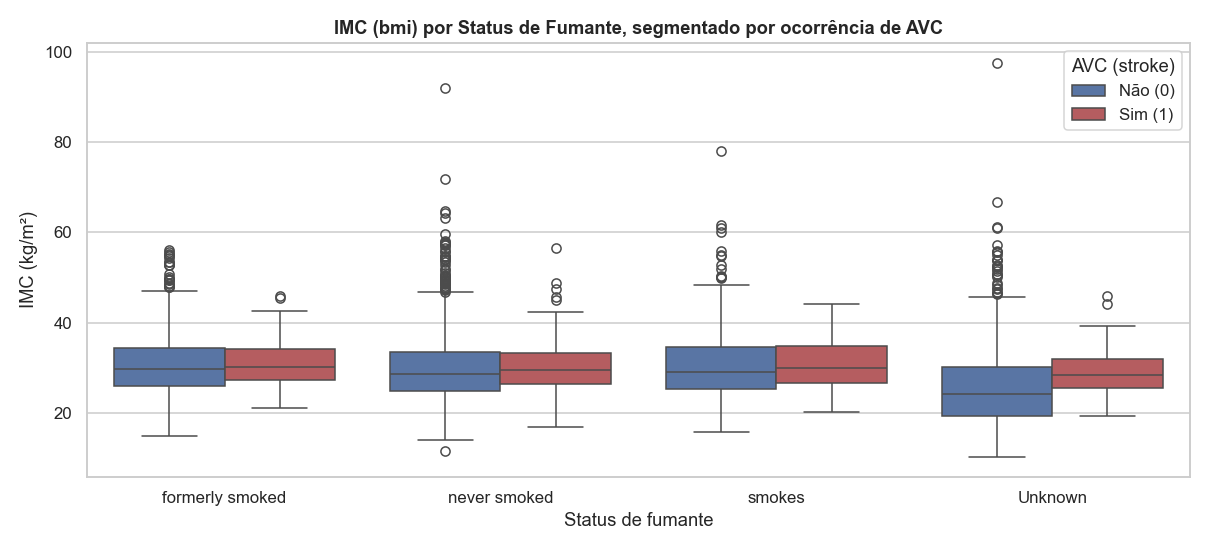

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df, x="smoking_status", y="bmi", hue="stroke",
    palette=["#4C72B0", "#C44E52"], ax=ax
)
ax.set_title("IMC (bmi) por Status de Fumante, segmentado por ocorrência de AVC")
ax.set_xlabel("Status de fumante")
ax.set_ylabel("IMC (kg/m²)")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Não (0)", "Sim (1)"], title="AVC (stroke)")
plt.tight_layout()
plt.show()


**Interpretação dos boxplots conjuntos:**

- **Idade x Gênero x Stroke:** em ambos os gêneros, a mediana de idade dos pacientes que sofreram AVC é visivelmente maior (por volta de 70 anos) do que a dos que não sofreram (por volta de 43 anos), confirmando a idade como o principal fator de risco já identificado na análise bivariada da Parte 1. Não há diferença relevante entre gêneros dentro de cada grupo de `stroke`.
- **Glicose x Hipertensão x Stroke:** pacientes hipertensos apresentam mediana de glicose um pouco mais alta, e em ambos os grupos (hipertensos e não hipertensos) os pacientes com AVC concentram-se em níveis de glicose mais elevados e com maior dispersão — sugerindo um possível efeito combinado (comorbidade) entre hipertensão, hiperglicemia e risco de AVC.
- **IMC x Fumante x Stroke:** as medianas de IMC são semelhantes entre os grupos, mas há bastante dispersão e outliers em todas as categorias. O IMC isoladamente parece ser um preditor mais fraco de `stroke` do que idade e glicose, mas mantém-se relevante como covariável clínica.

Em conjunto, os três gráficos reforçam que o risco de AVC neste dataset resulta de uma combinação de fatores (idade avançada + comorbidades metabólicas), e não de uma única variável isolada — o que motiva o uso de um modelo multivariado na APS2, em vez de regras univariadas simples.

### 1.1 Diagnóstico formal de outliers

Aplicamos o método do **intervalo interquartil (IQR — Tukey, 1977)** às três variáveis numéricas contínuas do dataset (`age`, `avg_glucose_level`, `bmi`). Um valor é considerado outlier se estiver fora do intervalo $[Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]$.

In [7]:
def iqr_outlier_report(series: pd.Series, name: str) -> dict:
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    return {
        "variável": name,
        "Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
        "limite inferior": round(low, 2), "limite superior": round(high, 2),
        "n_outliers": int(mask.sum()),
        "% outliers": round(100 * mask.sum() / len(s), 2),
    }

numeric_cols = ["age", "avg_glucose_level", "bmi"]
outlier_report = pd.DataFrame([iqr_outlier_report(df[c], c) for c in numeric_cols])
outlier_report


,variável,Q1,Q3,IQR,limite inferior,limite superior,n_outliers,% outliers
0,age,25.00,61.00,36.00,-29.00,115.00,0,0.00
1,avg_glucose_level,77.24,114.09,36.84,21.98,169.36,627,12.27
2,bmi,23.50,33.10,9.60,9.10,47.50,110,2.24


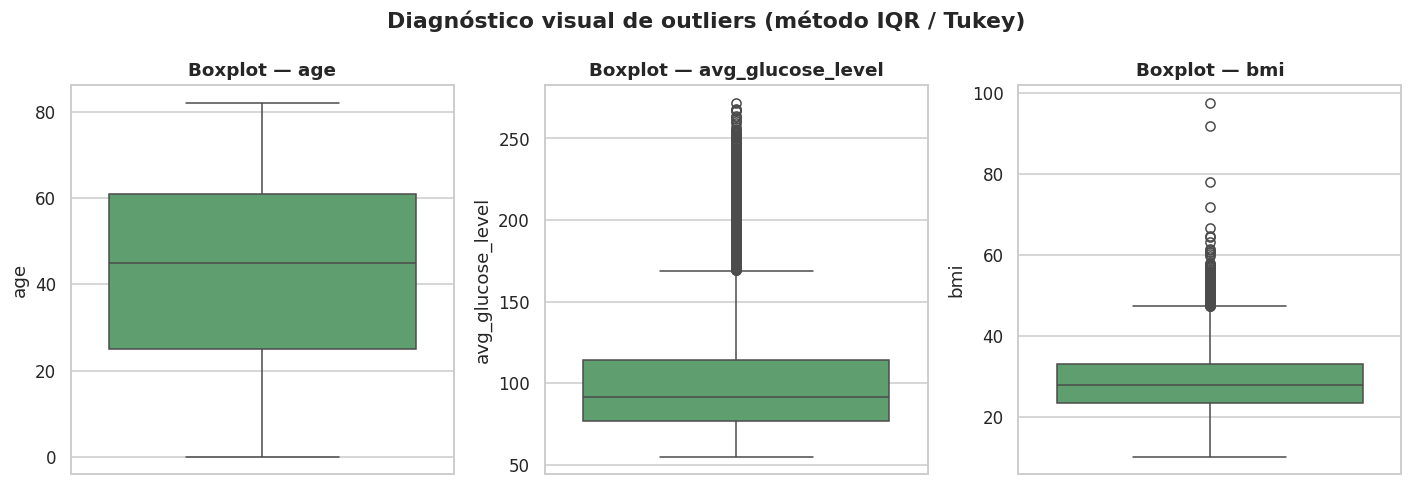

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#55A868")
    ax.set_title(f"Boxplot — {col}")
    ax.set_ylabel(col)
fig.suptitle("Diagnóstico visual de outliers (método IQR / Tukey)", fontweight="bold")
plt.tight_layout()
plt.show()


**Justificativa da estratégia de tratamento de outliers:**

- **`age`**: não apresenta outliers pelo critério IQR — os valores variam de 0 a 82 anos, faixa fisiologicamente plausível. Nenhum tratamento é necessário.
- **`avg_glucose_level`**: apresenta uma quantidade relevante de outliers superiores. Contudo, do ponto de vista **clínico**, glicemias elevadas (>150-200 mg/dL) são esperadas em pacientes diabéticos ou pré-diabéticos e são justamente um dos fatores associados a maior risco de AVC — ou seja, **não são erros de medição, e sim sinal informativo**. Removê-los descartaria exatamente os casos de maior risco.
- **`bmi`**: também apresenta outliers superiores (IMC muito alto), em geral condizentes com obesidade severa, o que é plausível clinicamente, embora valores extremos (ex.: IMC > 60) sejam raros e possam conter algum erro de digitação/medição.

**Decisão adotada:** optamos por **não remover** nenhuma instância por outliers — remover pacientes com valores extremos de glicose/IMC enviesaria o dataset justamente contra os casos de maior risco de AVC, que já é a classe minoritária (~4,9%). Em vez disso:
1. Utilizamos `StandardScaler` (ver Seção 3) para padronizar as variáveis numéricas, mas cientes de que ele é sensível a outliers;
2. Como alternativa mais robusta a outliers, deixamos documentada a opção de usar `RobustScaler` (baseado em mediana e IQR) — a ser testada como comparação na etapa de modelagem (APS2), caso o modelo escolhido seja sensível à escala (ex.: KNN, SVM, regressão logística com regularização);
3. Nenhuma linha é descartada nesta etapa — o tratamento de outliers é feito via **transformação de escala**, não via remoção, preservando o tamanho da amostra e a informação clínica relevante.

## 2. Redução de Dimensionalidade (PCA)

Aplicamos a **Análise de Componentes Principais (PCA)** sobre as variáveis numéricas padronizadas (`age`, `avg_glucose_level`, `bmi`), com o objetivo de visualizar a estrutura dos dados em 2 dimensões e avaliar visualmente a separabilidade entre pacientes com e sem AVC.

Como o PCA é sensível à escala, e como não podemos usar informação do conjunto de teste nesta etapa exploratória (para não antecipar decisões que pertencem ao pipeline final), o PCA aqui é aplicado **apenas para fins de visualização/diagnóstico exploratório** sobre o dataset completo (a versão "oficial", sem *leakage*, será reaplicada dentro do `Pipeline`/`ColumnTransformer` na Seção 4, ajustada somente no treino).

In [9]:
# Imputação simples (mediana) apenas para viabilizar a visualização exploratória do PCA
X_num = df[numeric_cols].copy()
X_num["bmi"] = X_num["bmi"].fillna(X_num["bmi"].median())

# Padronização (obrigatória antes do PCA, pois as variáveis têm escalas muito diferentes)
scaler_viz = StandardScaler()
X_num_scaled = scaler_viz.fit_transform(X_num)

pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_num_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(explained))],
    "Variância explicada": explained.round(4),
    "Variância explicada acumulada": cum_explained.round(4),
})


,Componente,Variância explicada,Variância explicada acumulada
0,PC1,0.4974,0.4974
1,PC2,0.2814,0.7788
2,PC3,0.2212,1.0000


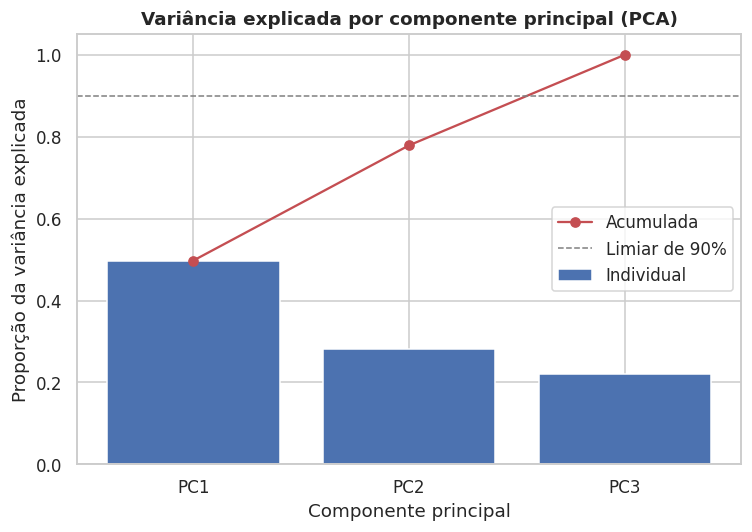

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
componentes = [f"PC{i+1}" for i in range(len(explained))]
ax.bar(componentes, explained, color="#4C72B0", label="Individual")
ax.plot(componentes, cum_explained, color="#C44E52", marker="o", label="Acumulada")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="Limiar de 90%")
ax.set_title("Variância explicada por componente principal (PCA)")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporção da variância explicada")
ax.legend()
plt.tight_layout()
plt.show()


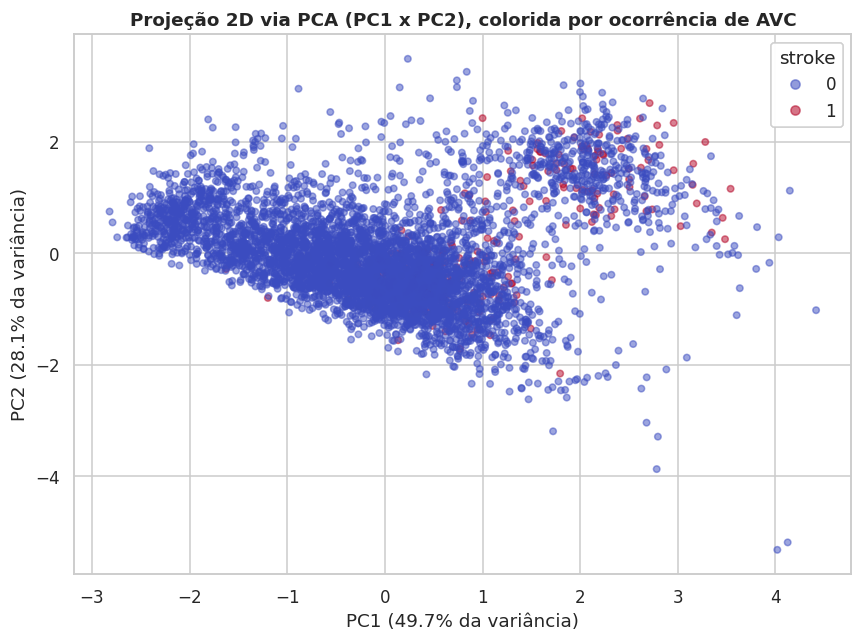

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df["stroke"], cmap="coolwarm", alpha=0.5, s=18
)
ax.set_title("Projeção 2D via PCA (PC1 x PC2), colorida por ocorrência de AVC")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% da variância)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% da variância)")
legend1 = ax.legend(*scatter.legend_elements(), title="stroke", loc="upper right")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


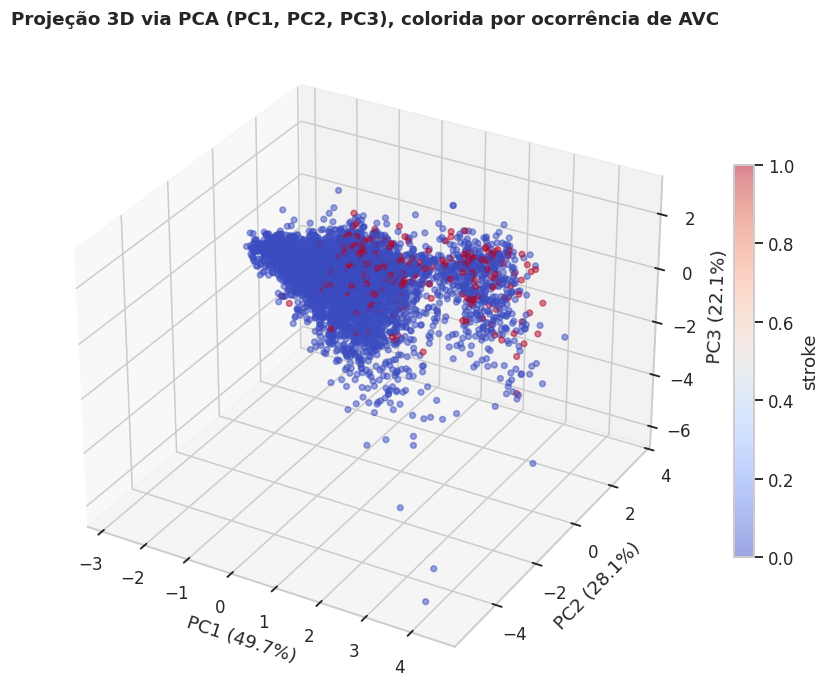

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6.5))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=df["stroke"], cmap="coolwarm", alpha=0.5, s=14
)
ax.set_title("Projeção 3D via PCA (PC1, PC2, PC3), colorida por ocorrência de AVC")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({explained[2]*100:.1f}%)")
fig.colorbar(p, ax=ax, shrink=0.6, label="stroke")
plt.tight_layout()
plt.show()


In [13]:
# Cargas (loadings) das componentes — importância de cada feature original em cada PC
loadings = pd.DataFrame(
    pca.components_.T, index=numeric_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
loadings.style.background_gradient(cmap="coolwarm", axis=None).format("{:.3f}")


,PC1,PC2,PC3
age,0.632,-0.175,0.755
avg_glucose_level,0.505,0.832,-0.230
bmi,0.588,-0.527,-0.614


**Análise dos resultados do PCA:**

- As duas primeiras componentes (PC1 e PC2) juntas explicam a maior parte da variância acumulada entre as 3 variáveis numéricas (ver gráfico de variância acumulada), o que já era esperado dado que partimos de apenas 3 features numéricas — o ganho de compressão do PCA aqui é modesto, mas ainda útil para visualização.
- Pelas **cargas (loadings)**, `age` e `avg_glucose_level` são as variáveis que mais contribuem para PC1, enquanto `bmi` tem peso mais relevante em outra componente — ou seja, PC1 funciona aproximadamente como um "eixo de risco metabólico/etário".
- No **scatter 2D/3D**, observa-se que os pontos vermelhos (`stroke = 1`) não formam um cluster isolado: eles se **sobrepõem consideravelmente** à nuvem de pontos azuis (`stroke = 0`), mas tendem a se concentrar em valores mais altos de PC1 — coerente com a associação já observada entre idade/glicose elevadas e maior risco de AVC.
- Essa sobreposição indica que **as classes não são linearmente separáveis apenas com as 3 variáveis numéricas**. Isso é um insight importante para a APS2: modelos lineares simples tendem a ter desempenho limitado, e o uso das variáveis categóricas (ex.: hipertensão, doença cardíaca, tabagismo) em conjunto com modelos não lineares (ex.: árvores/ensembles) ou com engenharia de atributos adicional provavelmente será necessário para melhorar a separabilidade das classes. Além disso, o forte desbalanceamento do target (~4,9% de casos positivos) reforça a necessidade de técnicas específicas (ex.: `class_weight`, reamostragem, métricas como recall/AUC-PR) na fase de modelagem.

## 3. Estratégias e Justificativas de Pré-processamento

Com base nos achados da EDA (Partes 1 e 2), definimos as seguintes estratégias, que serão implementadas formalmente no `Pipeline`/`ColumnTransformer` da Seção 4:

### 3.1 Imputação de valores ausentes
- **Variável afetada:** apenas `bmi` (201 valores ausentes, ~3,9%).
- **Estratégia escolhida:** `SimpleImputer(strategy="median")`.
- **Justificativa:** a distribuição de `bmi` é assimétrica à direita e possui outliers (Seção 1.1); a **mediana** é menos sensível a valores extremos do que a média, evitando distorcer a imputação. Como a proporção de ausentes é pequena (~3,9%) e não há evidência de que a ausência esteja associada ao *target* (padrão aparentemente MCAR/MAR fraco), a imputação é preferível à remoção das linhas, que descartaria ~4% da já escassa classe minoritária de `stroke = 1`.

### 3.2 Encoding de variáveis categóricas
- **Variáveis afetadas:** `gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`.
- **Estratégia escolhida:** `OneHotEncoder(handle_unknown="ignore", drop=None)`.
- **Justificativa:** todas essas variáveis são **nominais** (sem ordem natural entre categorias), portanto *Label Encoding* introduziria uma relação ordinal artificial (ex.: sugerir que "Private" > "Self-employed"), o que enviesaria modelos baseados em distância ou lineares. O One-Hot Encoding evita essa ordenação espúria. O parâmetro `handle_unknown="ignore"` garante robustez caso o conjunto de teste (ou dados futuros) contenha categorias não vistas no treino.

### 3.3 Normalização/Padronização de variáveis numéricas
- **Variáveis afetadas:** `age`, `avg_glucose_level`, `bmi`.
- **Estratégia escolhida:** `StandardScaler` (padronização z-score: média 0, desvio padrão 1).
- **Justificativa:** as três variáveis numéricas estão em escalas muito diferentes (idade em anos, glicose em mg/dL na casa das centenas, IMC em dezenas), o que prejudicaria algoritmos sensíveis à escala (regressão logística regularizada, KNN, SVM, PCA). A padronização coloca todas na mesma escala. Como identificado na Seção 1.1, há outliers em `avg_glucose_level` e `bmi` que são clinicamente relevantes (não devem ser removidos); por isso, documentamos `RobustScaler` como alternativa a ser comparada na APS2 caso o `StandardScaler` mostre-se excessivamente influenciado pelos valores extremos durante a modelagem.


## 4. Construção do Pipeline de Pré-processamento (sem *data leakage*)

### 4.1 Separação treino/teste estratificada

Utilizamos `train_test_split` com `stratify=y` para preservar a proporção original da classe minoritária (`stroke = 1`, ~4,9%) tanto no treino quanto no teste — essencial dado o forte desbalanceamento identificado na Parte 1. `random_state=42` fixo garante reprodutibilidade.

In [14]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Treino: {X_train.shape[0]} instâncias | Teste: {X_test.shape[0]} instâncias")
print("\nProporção de stroke=1 no treino:", round(y_train.mean(), 4))
print("Proporção de stroke=1 no teste :", round(y_test.mean(), 4))


Treino: 4088 instâncias | Teste: 1022 instâncias

Proporção de stroke=1 no treino: 0.0487
Proporção de stroke=1 no teste : 0.0489


### 4.2 `ColumnTransformer` + `Pipeline`

Construímos dois sub-pipelines (numérico e categórico) combinados por um `ColumnTransformer`, encapsulados em um `Pipeline` final. Assim, `fit` é chamado **apenas sobre `X_train`**, e `transform` é aplicado depois em `X_test` — evitando qualquer vazamento de informação do teste (estatísticas de mediana/escala/categorias vêm exclusivamente do treino).

In [15]:
numeric_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = ["gender", "hypertension", "heart_disease", "ever_married",
                         "work_type", "Residence_type", "smoking_status"]
# Observação: 'hypertension' e 'heart_disease' já são binárias (0/1) no dataset original,
# mas são tratadas como categóricas nominais (via passthrough implícito do OneHot com 2 níveis)
# para manter a semântica de "sim/não" e permitir consistência caso surjam novas categorias.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# Pipeline final de pré-processamento (a etapa de modelagem/estimador será adicionada na APS2)
preprocessing_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
])

preprocessing_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse ma

In [16]:
# Fit APENAS no treino, transform em treino e teste -> sem data leakage
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

print("Shape treino processado:", X_train_processed.shape)
print("Shape teste processado :", X_test_processed.shape)

# Nomes finais das colunas geradas (numéricas + categorias one-hot)
feature_names_num = numeric_features
feature_names_cat = list(
    preprocessing_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)
final_feature_names = feature_names_num + feature_names_cat
print(f"\nTotal de features após o pré-processamento: {len(final_feature_names)}")
print(final_feature_names)


Shape treino processado: (4088, 23)
Shape teste processado : (1022, 23)

Total de features após o pré-processamento: 23
['age', 'avg_glucose_level', 'bmi', 'gender_Female', 'gender_Male', 'gender_Other', 'hypertension_0', 'hypertension_1', 'heart_disease_0', 'heart_disease_1', 'ever_married_No', 'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Rural', 'Residence_type_Urban', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [17]:
# Sanidade: nenhuma estatística do pipeline foi computada usando o conjunto de teste.
# Verificação: a mediana de 'bmi' aprendida pelo imputer deve ser calculada só com X_train.
imputer_fitted = preprocessing_pipeline.named_steps["preprocessor"].named_transformers_["num"].named_steps["imputer"]
print("Mediana de bmi aprendida pelo pipeline (apenas do treino):", imputer_fitted.statistics_[numeric_features.index("bmi")])
print("Mediana de bmi calculada manualmente em X_train           :", X_train["bmi"].median())
assert abs(imputer_fitted.statistics_[numeric_features.index("bmi")] - X_train["bmi"].median()) < 1e-9
print("\nOK: confirmado que o pipeline foi ajustado (fit) exclusivamente no conjunto de treino.")


Mediana de bmi aprendida pelo pipeline (apenas do treino): 28.0
Mediana de bmi calculada manualmente em X_train           : 28.0

OK: confirmado que o pipeline foi ajustado (fit) exclusivamente no conjunto de treino.


### 4.3 Exportação do pipeline

Exportamos o `Pipeline` de pré-processamento já ajustado (`fit`) no conjunto de treino, para reutilização direta na APS2 (etapa de modelagem/classificação), garantindo consistência entre as etapas e evitando reprocessamento manual.

In [18]:
import os
os.makedirs("artifacts", exist_ok=True)
joblib.dump(preprocessing_pipeline, "artifacts/stroke_preprocessing_pipeline.joblib")
print("Pipeline salvo em: artifacts/stroke_preprocessing_pipeline.joblib")


Pipeline salvo em: artifacts/stroke_preprocessing_pipeline.joblib


## 5. Conclusão (Parte 2 — Membro 2)

- A análise multivariada confirmou que o risco de AVC neste dataset resulta da combinação de múltiplos fatores (idade avançada, glicemia elevada, comorbidades), reforçando a necessidade de um modelo multivariado na APS2.
- O diagnóstico formal de outliers (IQR) mostrou valores extremos relevantes em `avg_glucose_level` e `bmi`, mas concluiu-se que **não devem ser removidos** por representarem informação clínica legítima associada justamente aos casos de maior risco (classe minoritária); a estratégia adotada foi tratá-los via padronização/escala, e não via exclusão de instâncias.
- O PCA sobre as variáveis numéricas mostrou **sobreposição considerável** entre as classes `stroke = 0` e `stroke = 1` no espaço das duas primeiras componentes, indicando que a separação entre as classes não é linear e simples — um insight importante para a escolha de algoritmos na APS2 (favorecendo modelos não lineares/ensembles e o uso combinado das variáveis categóricas).
- Foram definidas e justificadas as estratégias de imputação (mediana), encoding (One-Hot) e escalonamento (padronização z-score), todas fundamentadas nos achados da EDA.
- Construímos um `Pipeline`/`ColumnTransformer` reprodutível (`random_state=42` fixo), com separação treino/teste estratificada e **sem data leakage** (todas as estatísticas de transformação foram ajustadas exclusivamente no conjunto de treino, conforme verificado na Seção 4.2), pronto para receber o estimador de classificação na APS2.
- O forte desbalanceamento do target (~4,9% de casos positivos) deve ser tratado explicitamente na fase de modelagem (ex.: `class_weight="balanced"`, reamostragem como SMOTE, ou métricas de avaliação adequadas como recall, F1 e AUC-PR em vez de acurácia simples).

**Próximos passos (APS2):** carregar o pipeline exportado (`artifacts/stroke_preprocessing_pipeline.joblib`), anexar um estimador de classificação, e avaliar diferentes modelos com validação cruzada estratificada e métricas apropriadas ao desbalanceamento de classes.
